In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.seasonal import seasonal_decompose

# importing util
import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

print('finished imports!')

Mounted at /content/drive
finished imports!


In [ ]:
aggregated_data = pd.read_csv('/content/drive/MyDrive/DSSI/Project/Valley Fever - Environmental/data_processed/aggregate/aggregate_all_counties_2001_2024.csv', parse_dates=['Year-Month'])
aggregated_data['log1p_rate_per_100k'] = np.log1p(aggregated_data['rate_per_100k'])
aggregated_data_trimmed = aggregated_data[(aggregated_data["Year-Month"] >= "2006-08") & (aggregated_data["Year-Month"] <= "2023-12")]

# interpolating the NaN values in Tulare
cols = ['AQI_PM10', 'Avg Soil Temp (F)']

tulare_mask = aggregated_data_trimmed['County'] == "Tulare"

aggregated_data_trimmed.loc[tulare_mask, cols] = (
    aggregated_data_trimmed.loc[tulare_mask, cols]
    .apply(lambda s: s.interpolate(method="linear"))
)

In [ ]:
monthly_all_df = pd.read_csv('/content/drive/MyDrive/DSSI/Project/data/monthly_dataset.csv', parse_dates=['Year-Month'])
monthly_all_df['log1p_rate_per_100k'] = np.log1p(monthly_all_df['rate_per_100k'])
monthly_all_trimmed = monthly_all_df[(monthly_all_df["Year-Month"] >= "2006-08-01") & (monthly_all_df["Year-Month"] <= "2023-12-01")].copy()

#### LR with log1p-diff rate with ALL exog

In [6]:
for lag in range(1, 13):
    monthly_all_trimmed[f"log1p_diff_rate_lag{lag}"] = (
        monthly_all_trimmed["log1p_diff_rate_per_100k"].shift(lag)
    )

X = monthly_all_trimmed[[
    'log1p_diff_rate_lag1',
    'log1p_diff_rate_lag2',
    'log1p_diff_rate_lag3',
    'log1p_diff_rate_lag4',
    'log1p_diff_rate_lag5',
    'log1p_diff_rate_lag6',
    'log1p_diff_rate_lag7',
    'log1p_diff_rate_lag8',
    'log1p_diff_rate_lag9',
    'log1p_diff_rate_lag10',
    'log1p_diff_rate_lag11',
    'log1p_diff_rate_lag12',
    'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    'AQI_PM25',
    'AQI_PM10',
    'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
    ]]
y = monthly_all_trimmed['log1p_diff_rate_per_100k']
dates = monthly_all_trimmed['Year-Month']

X = X.iloc[13:]
y = y.iloc[13:]
dates = dates.iloc[13:]

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

KeyError: 'log1p_diff_rate_per_100k'

In [ ]:
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

all_features_lr = LinearRegression(fit_intercept=True)
all_features_lr.fit(X_train, y_train)

lr_preds_log_diff = all_features_lr.predict(X_test)

last_train_log_rate = fresno_df.loc[y_train.index[-1], "log1p_rate_per_100k"]

pred_log_rate = last_train_log_rate + np.cumsum(lr_preds_log_diff)
actual_log_rate = fresno_df.loc[y_test.index, "log1p_rate_per_100k"].values

lr_preds_original = np.expm1(pred_log_rate)
y_test_original = np.expm1(actual_log_rate)

utils.compute_metrics(y_test_original, lr_preds_original)

# testing lags and features selected from day 12

#### fresno

In [ ]:
fresno_df = aggregated_data_trimmed[aggregated_data_trimmed['County'] == 'Fresno'].copy()

In [ ]:
fresno_lag_dict = {
    # 'log1p_diff_rate_per_100k': 12,
    'windeventcount': [3],
    'fungicide_lbs_prd_used': [1],
    'AQI_PM10': [3],
    'Avg Soil Temp (F)': [1],
    'Wind Run (miles)': [2]
}

In [ ]:
X, y = utils.make_custom_lag_matrix(
    df=fresno_df,
    target_col="log1p_diff_rate_per_100k",
    lag_dict=fresno_lag_dict,
    drop_na=True
)

dates = fresno_df.loc[X.index, "Year-Month"]

In [ ]:
X

,windeventcount_lag3,fungicide_lbs_prd_used_lag1,AQI_PM10_lag3,Avg Soil Temp (F)_lag1,Wind Run (miles)_lag2
70,0.000000,21487.1846,37.0,63.884946,3109.000000
71,0.000000,6044.5023,58.0,58.401111,2732.816667
72,0.166667,11001.3873,35.0,49.833129,2785.400000
73,0.166667,41852.1624,44.5,44.721544,3047.033333
74,1.166667,70876.6081,50.5,51.170238,2836.550000
...,...,...,...,...,...
271,0.000000,93058.2991,27.0,81.276058,3685.671429
272,0.000000,87691.2388,35.5,80.743011,3378.300000
273,0.000000,47532.2540,43.0,77.451823,3250.057143
274,0.000000,20642.4119,47.0,70.492888,3012.685714


In [ ]:
# Align dates with retained observations
dates = fresno_df.loc[
    X.index,
    "Year-Month"
]

assert X.index.equals(y.index)
assert X.index.equals(dates.index)
assert not X.isna().any().any()
assert not y.isna().any()

In [ ]:
TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

dates_train = dates.iloc[:split]
dates_test = dates.iloc[split:]

In [ ]:
custom_lag_lr = LinearRegression(fit_intercept=True)
custom_lag_lr.fit(X_train, y_train)

# Predict the change in log1p(rate)
predicted_log_differences = custom_lag_lr.predict(X_test)

# Last observed log1p(rate) in the training period
last_train_log_rate = fresno_df.loc[y_train.index[-1], "log1p_rate_per_100k"]

# Actual log1p(rate) values during the test period
actual_test_log_rate = fresno_df.loc[y_test.index, "log1p_rate_per_100k"].to_numpy()

# Previous actual log1p(rate) for every test observation

# First test prediction uses the final training observation.
# Every later prediction uses the actual rate from the previous test month.
previous_actual_log_rate = np.concatenate([[last_train_log_rate], actual_test_log_rate[:-1]])

# Add the predicted change to the previous actual logged rate
one_step_pred_log_rate = (previous_actual_log_rate + predicted_log_differences)

# Convert actual and predicted values back to rate_per_100k
one_step_preds_original = np.expm1(one_step_pred_log_rate)

y_test_original = np.expm1(actual_test_log_rate)

In [ ]:
prediction_results = pd.DataFrame({
    "Year-Month": dates_test.to_numpy(),
    "Actual_Rate": y_test_original,
    "Predicted_Rate": one_step_preds_original,
    "Actual_Log_Difference": y_test.to_numpy(),
    "Predicted_Log_Difference": predicted_log_differences
})

prediction_results

,Year-Month,Actual_Rate,Predicted_Rate,Actual_Log_Difference,Predicted_Log_Difference
0,2020-07-01,2.676837,3.708220,-0.102426,0.144830
1,2020-08-01,3.668259,3.132226,0.238733,0.116763
2,2020-09-01,3.370832,3.859925,-0.065833,0.040237
3,2020-10-01,4.064827,3.375608,0.147367,0.001092
4,2020-11-01,4.163969,3.644419,0.019386,-0.086654
5,2020-12-01,3.370832,2.918040,-0.166752,-0.276114
6,2021-01-01,3.373933,2.377819,0.000709,-0.257723
7,2021-02-01,2.778533,2.936573,-0.146327,-0.105352
8,2021-03-01,3.870100,2.673673,0.253779,-0.028144
9,2021-04-01,3.572400,3.749480,-0.063076,-0.025079


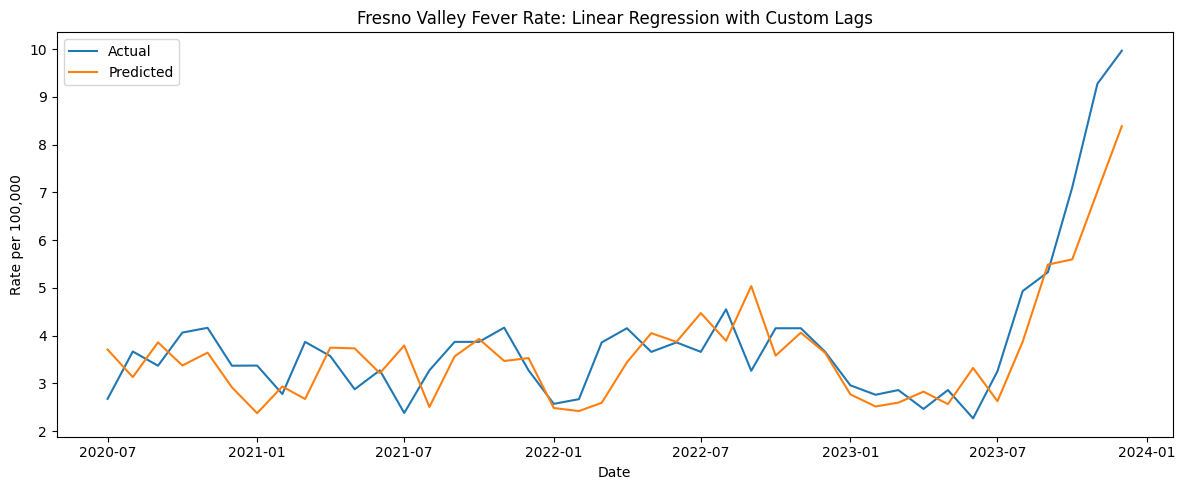

Model                           RMSE=0.82792   MAE=0.64066
RMSE for original scaled rate: {'RMSE': np.float64(0.8279161986372096), 'MAE': 0.6406555755542588}
Model                           RMSE=0.16272   MAE=0.13182
RMSE for log-diffed rate: {'RMSE': np.float64(0.16271804126449654), 'MAE': 0.131816676421596}


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    prediction_results["Year-Month"],
    prediction_results["Actual_Rate"],
    label="Actual"
)

plt.plot(
    prediction_results["Year-Month"],
    prediction_results["Predicted_Rate"],
    label="Predicted"
)

plt.title(
    "Fresno Valley Fever Rate: "
    "Linear Regression with Custom Lags"
)

plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()
plt.tight_layout()
plt.show()

print('RMSE for original scaled rate:', utils.compute_metrics(y_test_original, one_step_preds_original))
print('RMSE for log-diffed rate:', utils.compute_metrics(y_test, predicted_log_differences))

#### kern

In [ ]:
kern_df = aggregated_data_trimmed[aggregated_data_trimmed['County'] == 'Kern'].copy()

In [ ]:
kern_lag_dict = {
    # 'log1p_diff_rate_per_100k': 12,
    'Avg Rel Hum (%)': [7],
    'fungicide_lbs_prd_used': [4],
    'Avg Soil Temp (F)': [1]
}

In [ ]:
X, y = utils.make_custom_lag_matrix(
    df=kern_df,
    target_col="log1p_diff_rate_per_100k",
    lag_dict=kern_lag_dict,
    drop_na=True
)

dates = kern_df.loc[X.index, "Year-Month"]

In [ ]:
X

,Avg Rel Hum (%)_lag7,fungicide_lbs_prd_used_lag4,Avg Soil Temp (F)_lag1
362,47.634409,3278.0071,54.584524
363,45.555556,2635.7261,61.733333
364,60.172043,22554.1986,66.285556
365,74.277778,24699.8493,73.956989
366,68.741935,93093.5307,80.070635
...,...,...,...
559,73.048387,79391.6915,84.722581
560,59.401786,140056.8024,83.668548
561,65.443548,143884.1164,78.710833
562,48.266667,121591.1850,71.184677


In [ ]:
TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

dates_train = dates.iloc[:split]
dates_test = dates.iloc[split:]

In [ ]:
custom_lag_lr = LinearRegression(fit_intercept=True)
custom_lag_lr.fit(X_train, y_train)

# Predict the change in log1p(rate)
predicted_log_differences = custom_lag_lr.predict(X_test)

# Last observed log1p(rate) in the training period
last_train_log_rate = kern_df.loc[y_train.index[-1], "log1p_rate_per_100k"]

# Actual log1p(rate) values during the test period
actual_test_log_rate = kern_df.loc[y_test.index, "log1p_rate_per_100k"].to_numpy()

# Previous actual log1p(rate) for every test observation

# First test prediction uses the final training observation.
# Every later prediction uses the actual rate from the previous test month.
previous_actual_log_rate = np.concatenate([[last_train_log_rate], actual_test_log_rate[:-1]])

# Add the predicted change to the previous actual logged rate
one_step_pred_log_rate = (previous_actual_log_rate + predicted_log_differences)

# Convert actual and predicted values back to rate_per_100k
one_step_preds_original = np.expm1(one_step_pred_log_rate)

y_test_original = np.expm1(actual_test_log_rate)

In [ ]:
prediction_results = pd.DataFrame({
    "Year-Month": dates_test.to_numpy(),
    "Actual_Rate": y_test_original,
    "Predicted_Rate": one_step_preds_original,
    "Actual_Log_Difference": y_test.to_numpy(),
    "Predicted_Log_Difference": predicted_log_differences
})

prediction_results

,Year-Month,Actual_Rate,Predicted_Rate,Actual_Log_Difference,Predicted_Log_Difference
0,2020-08-01,21.556797,20.842999,0.216955,0.184800
1,2020-09-01,22.876601,21.236560,0.056862,-0.014299
2,2020-10-01,29.475620,24.900006,0.244028,0.081344
3,2020-11-01,26.836012,29.431905,-0.090596,-0.001435
4,2020-12-01,25.846159,23.248153,-0.036208,-0.137990
5,2021-01-01,31.196605,23.003039,0.181738,-0.111942
6,2021-02-01,27.228132,26.616808,-0.131542,-0.153436
7,2021-03-01,26.787191,22.858435,-0.015744,-0.168181
8,2021-04-01,16.976244,23.064263,-0.435524,-0.143847
9,2021-05-01,23.259659,14.879822,0.299764,-0.124002


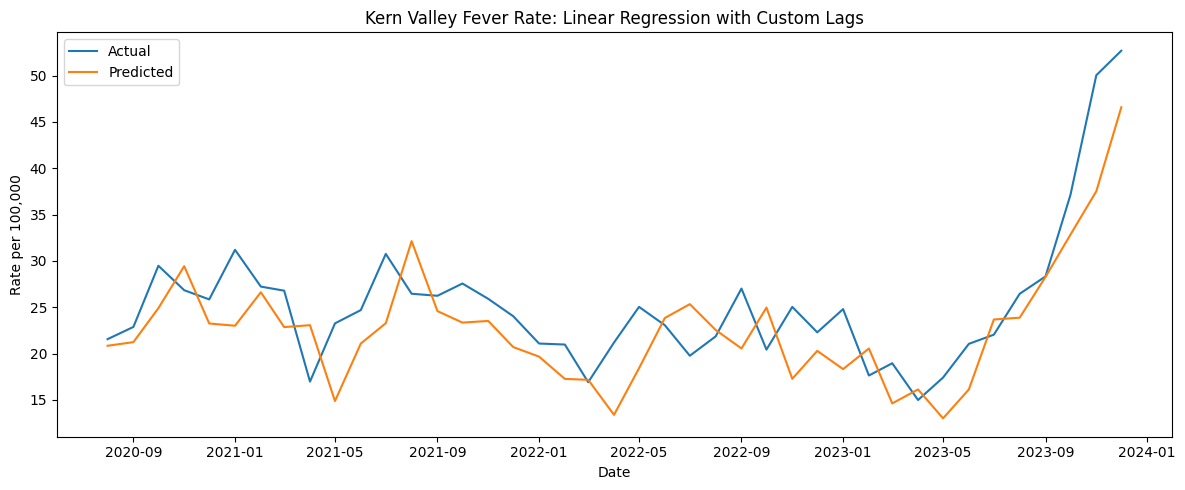

Model                           RMSE=4.89238   MAE=4.06459
RMSE for original scaled rate: {'RMSE': np.float64(4.892382961018862), 'MAE': 4.0645859791255665}
Model                           RMSE=0.20087   MAE=0.16731
RMSE for log-diffed rate: {'RMSE': np.float64(0.20086545272833448), 'MAE': 0.16730924084055906}


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    prediction_results["Year-Month"],
    prediction_results["Actual_Rate"],
    label="Actual"
)

plt.plot(
    prediction_results["Year-Month"],
    prediction_results["Predicted_Rate"],
    label="Predicted"
)

plt.title(
    "Kern Valley Fever Rate: "
    "Linear Regression with Custom Lags"
)

plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()
plt.tight_layout()
plt.show()

print('RMSE for original scaled rate:', utils.compute_metrics(y_test_original, one_step_preds_original))
print('RMSE for log-diffed rate:', utils.compute_metrics(y_test, predicted_log_differences))

# running  on all counties

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
selected_lags_by_county = {
    "Fresno": {
        "windeventcount": [3],
        "fungicide_lbs_prd_used": [1],
        "AQI_PM10": [3],
        "Avg Soil Temp (F)": [1],
        "Wind Run (miles)": [2]
    },

    "Kern": {
        "Avg Rel Hum (%)": [7],
        "fungicide_lbs_prd_used": [4],
        "Avg Soil Temp (F)": [1]
    },

    "Los Angeles": {
        "Avg Wind Speed (mph)": [1],
        "Precipitation": [5],
        "AQI_PM10": [6]
    },

    "Orange": {
        "Avg Soil Temp (F)": [7],
        "rodent_lbs_prd_used": [7],
        "FIRE_Acres_Burned": [3],
        "windeventcount": [10]
    },

    "San Diego": {
        "windeventcount": [3],
        "fungicide_lbs_prd_used": [5],
        "Avg Soil Temp (F)": [5],
        "AQI_PM10": [2]
    },

    "San Luis Obispo": {
        "fungicide_lbs_prd_used": [2],
        "Avg Soil Temp (F)": [1],
        "Avg Rel Hum (%)": [4],
        "windeventcount": [1]
    },

    "Tulare": {
        "Avg Soil Temp (F)": [6],
        "Precipitation": [12],
        "windeventcount": [12],
        "Avg Wind Speed (mph)": [2]
    },

    "Ventura": {
        "AQI_PM10": [1],
        "FIRE_Acres_Burned": [3],
        "Avg Rel Hum (%)": [3]
    }
}

In [ ]:
TRAIN_FRAC = 0.80

all_county_predictions = []
all_county_metrics = []
all_county_models = {}

for county, environmental_lags in selected_lags_by_county.items():

    print(f"Running {county}...")

    # ---------------------------------------------------------
    # Filter and sort one county
    # ---------------------------------------------------------
    county_df = (
        aggregated_data_trimmed[
            aggregated_data_trimmed["County"] == county
        ]
        .copy()
        .sort_values("Year-Month")
        .reset_index(drop=True)
    )

    # Create differenced log target within each county
    county_df["log1p_diff_rate_per_100k"] = (county_df["log1p_rate_per_100k"].diff())

    # ---------------------------------------------------------
    # Use only selected lagged environmental features
    # ---------------------------------------------------------
    lag_dict = {feature: [lag] for feature, lag in environmental_lags.items()}

    # Build custom lag matrix
    X, y = utils.make_custom_lag_matrix(
        df=county_df,
        target_col="log1p_diff_rate_per_100k",
        lag_dict=lag_dict,
        drop_na=True
    )

    # Align dates with remaining rows
    dates = county_df.loc[X.index, "Year-Month"]

    # ---------------------------------------------------------
    # Chronological train/test split
    # ---------------------------------------------------------
    split = int(TRAIN_FRAC * len(y))

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    dates_train = dates.iloc[:split]
    dates_test = dates.iloc[split:]

    # ---------------------------------------------------------
    # Fit linear regression
    # ---------------------------------------------------------
    model = LinearRegression(fit_intercept=True)

    model.fit(X_train, y_train)

    # Predict differenced log rates
    predicted_train_log_differences = model.predict(X_train)

    predicted_test_log_differences = model.predict(X_test)

    # ---------------------------------------------------------
    # Recursive reconstruction of training predictions
    # ---------------------------------------------------------
    first_train_index = y_train.index[0]

    # Actual logged rate immediately before first training target
    train_starting_log_rate = county_df.loc[first_train_index - 1, "log1p_rate_per_100k"]

    # Recursively reconstruct training logged rates
    recursive_train_log_rate = (train_starting_log_rate + np.cumsum(predicted_train_log_differences))

    train_predicted_rate = np.expm1(recursive_train_log_rate)

    # Actual training rates, used only for evaluation/plotting
    actual_train_log_rate = county_df.loc[y_train.index, "log1p_rate_per_100k"].to_numpy()

    train_actual_rate = np.expm1(actual_train_log_rate)

    # ---------------------------------------------------------
    # Recursive reconstruction of test predictions
    # ---------------------------------------------------------

    # Final actual logged rate available before test begins
    last_train_log_rate = county_df.loc[y_train.index[-1], "log1p_rate_per_100k"]

    # Recursively reconstruct test logged rates
    recursive_test_log_rate = (last_train_log_rate + np.cumsum(predicted_test_log_differences))

    predicted_rate = np.expm1(recursive_test_log_rate)

    # Actual test rates, used only for evaluation
    actual_test_log_rate = county_df.loc[y_test.index, "log1p_rate_per_100k"].to_numpy()

    actual_rate = np.expm1(actual_test_log_rate)

    # ---------------------------------------------------------
    # Test metrics on original rate scale
    # ---------------------------------------------------------
    rmse = np.sqrt(mean_squared_error(actual_rate, predicted_rate))

    mae = mean_absolute_error(actual_rate, predicted_rate)

    r2 = r2_score(actual_rate, predicted_rate)

    # ---------------------------------------------------------
    # Test metrics on differenced log scale
    # ---------------------------------------------------------
    log_diff_rmse = np.sqrt(mean_squared_error(y_test, predicted_test_log_differences))

    log_diff_mae = mean_absolute_error(y_test, predicted_test_log_differences)

    log_diff_r2 = r2_score(y_test, predicted_test_log_differences)

    # ---------------------------------------------------------
    # Store metrics
    # ---------------------------------------------------------
    all_county_metrics.append({
        "County": county,
        "Number_Train_Observations": len(X_train),
        "Number_Test_Observations": len(X_test),
        "Number_Features": X.shape[1],

        "Original_Scale_RMSE": rmse,
        "Original_Scale_MAE": mae,
        "Original_Scale_R2": r2,

        "Log_Difference_RMSE": log_diff_rmse,
        "Log_Difference_MAE": log_diff_mae,
        "Log_Difference_R2": log_diff_r2
    })

    # ---------------------------------------------------------
    # Store training predictions
    # ---------------------------------------------------------
    train_predictions_df = pd.DataFrame({
        "County": county,
        "Year-Month": dates_train.to_numpy(),
        "Actual_Rate": train_actual_rate,
        "Predicted_Rate": train_predicted_rate,
        "Actual_Log_Difference": y_train.to_numpy(),
        "Predicted_Log_Difference":
            predicted_train_log_differences,
        "Dataset": "Train"
    })

    # ---------------------------------------------------------
    # Store test predictions
    # ---------------------------------------------------------
    test_predictions_df = pd.DataFrame({
        "County": county,
        "Year-Month": dates_test.to_numpy(),
        "Actual_Rate": actual_rate,
        "Predicted_Rate": predicted_rate,
        "Actual_Log_Difference": y_test.to_numpy(),
        "Predicted_Log_Difference":
            predicted_test_log_differences,
        "Dataset": "Test"
    })

    county_predictions = pd.concat([train_predictions_df, test_predictions_df], ignore_index=True)

    all_county_predictions.append(county_predictions)

    # ---------------------------------------------------------
    # Store fitted model and associated data
    # ---------------------------------------------------------
    all_county_models[county] = {
        "model": model,
        "lag_dict": lag_dict,
        "feature_names": X.columns.tolist(),
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "dates_train": dates_train,
        "dates_test": dates_test
    }

Running Fresno...
Running Kern...
Running Los Angeles...
Running Orange...
Running San Diego...
Running San Luis Obispo...
Running Tulare...
Running Ventura...


In [ ]:
all_county_metrics_df = pd.DataFrame(all_county_metrics)

all_county_predictions_df = pd.concat(all_county_predictions, ignore_index=True)

# plots w/o rate

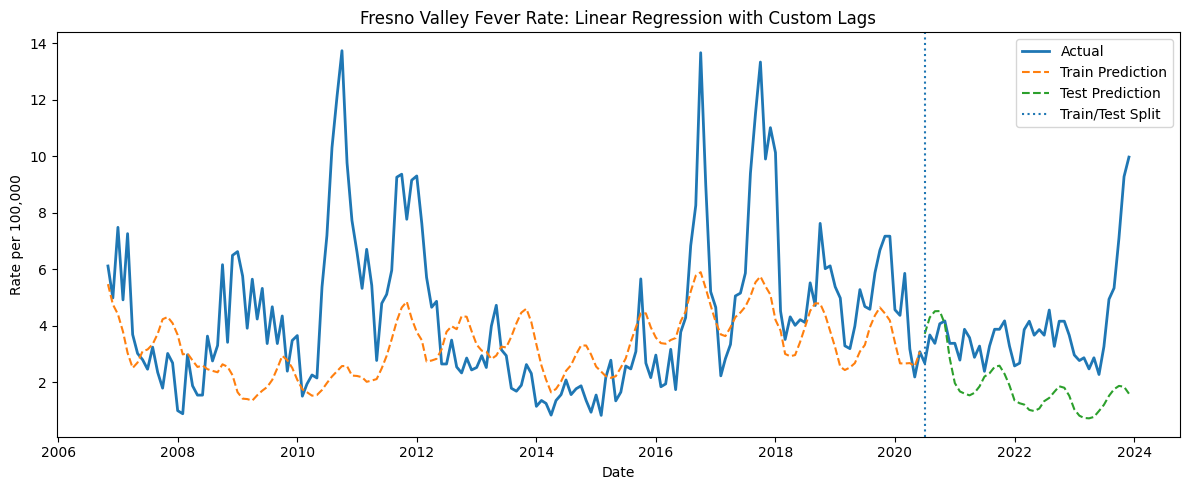

Fresno original-scale test RMSE: 2.6759
Fresno log-difference test RMSE: 0.1627


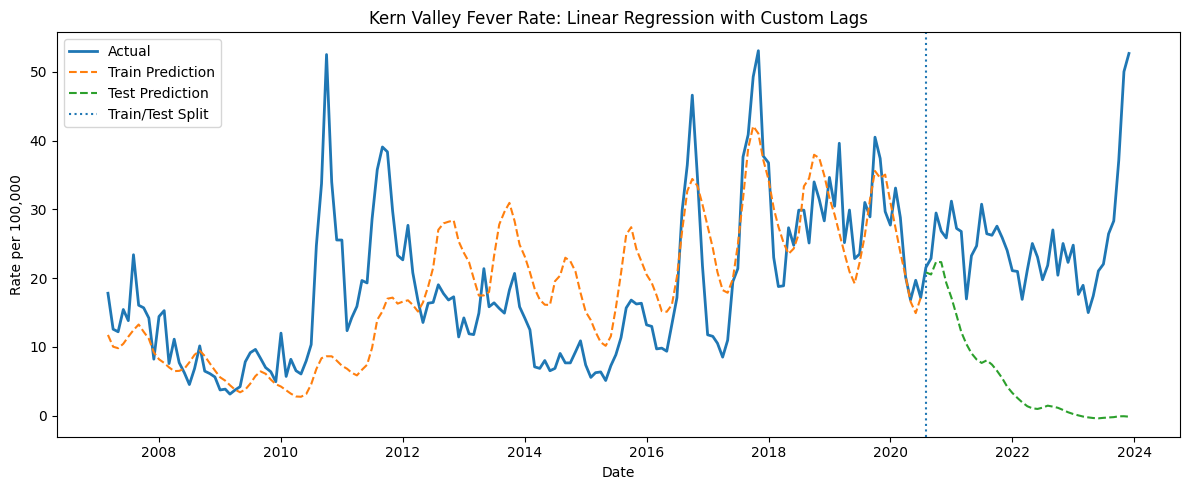

Kern original-scale test RMSE: 22.0195
Kern log-difference test RMSE: 0.2009


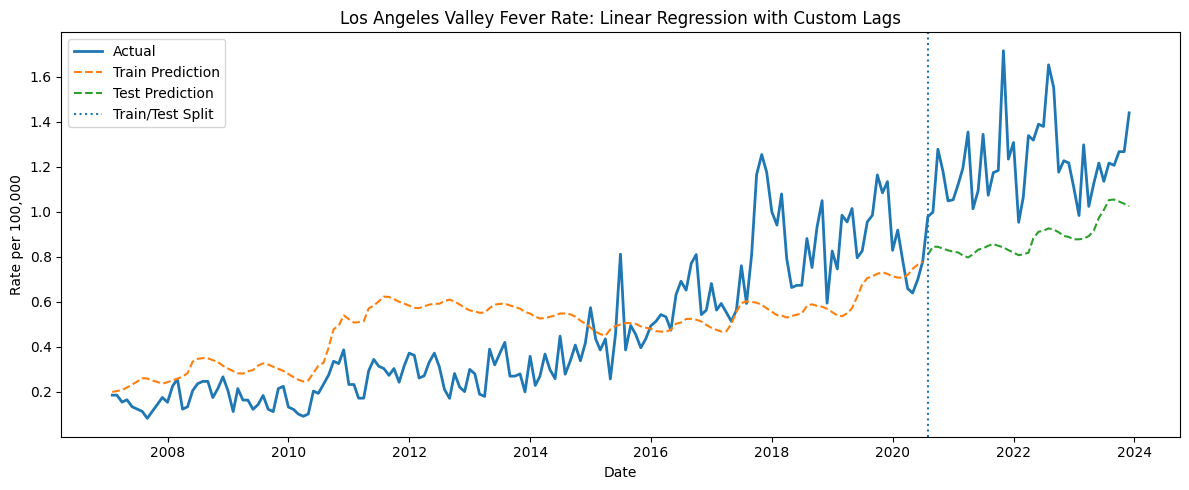

Los Angeles original-scale test RMSE: 0.3733
Los Angeles log-difference test RMSE: 0.0886


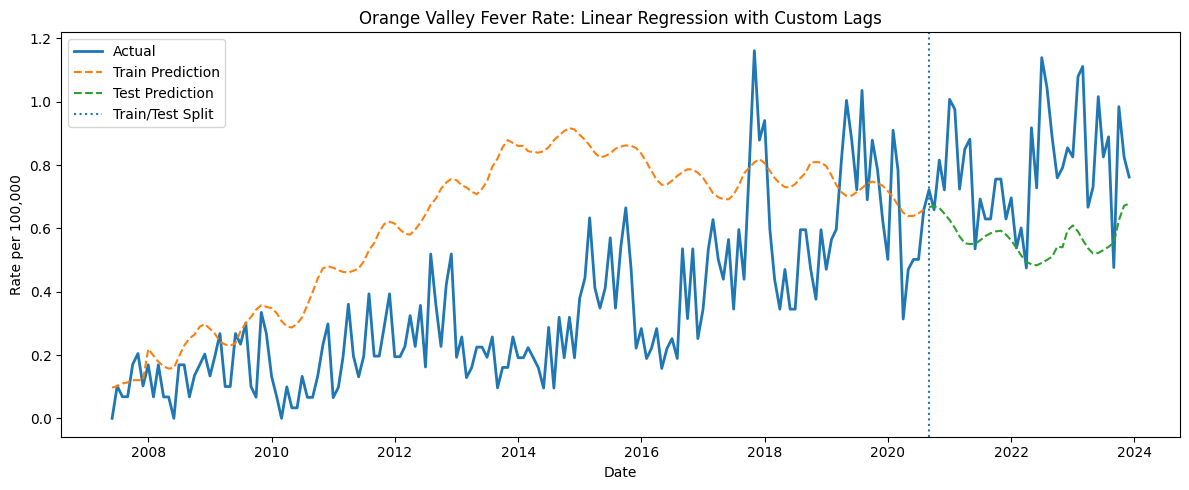

Orange original-scale test RMSE: 0.2824
Orange log-difference test RMSE: 0.1157


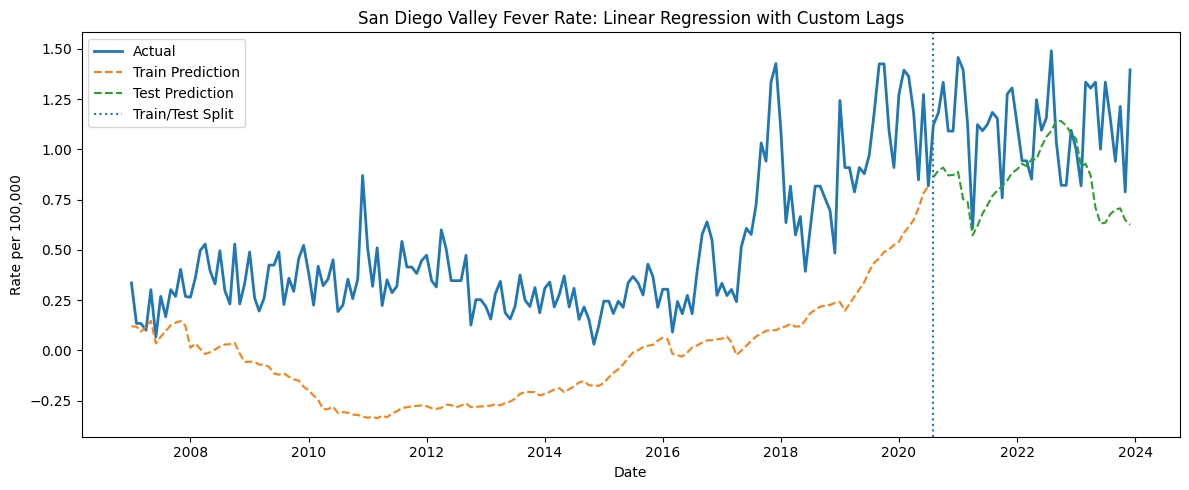

San Diego original-scale test RMSE: 0.3705
San Diego log-difference test RMSE: 0.1325


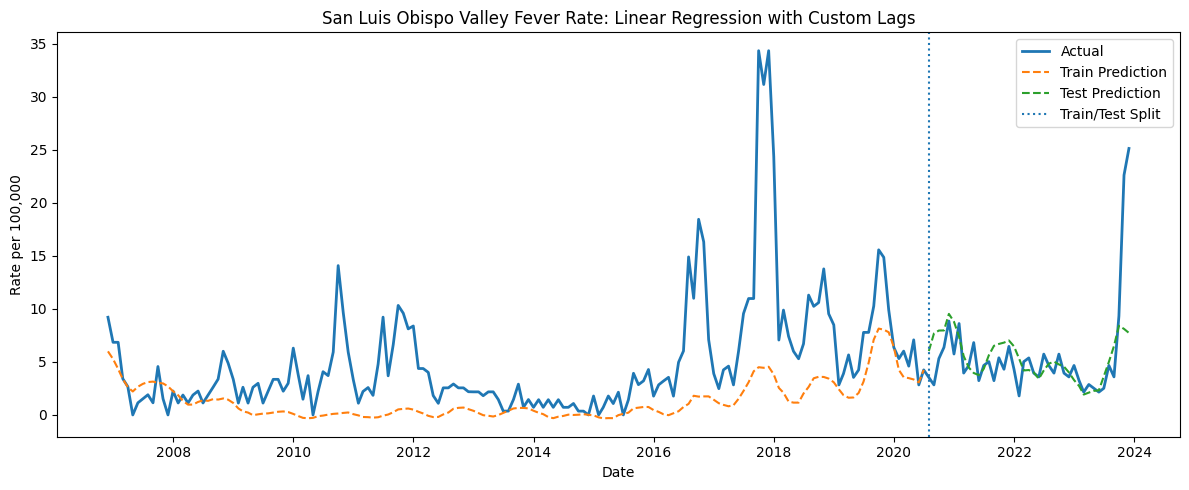

San Luis Obispo original-scale test RMSE: 3.9267
San Luis Obispo log-difference test RMSE: 0.3680


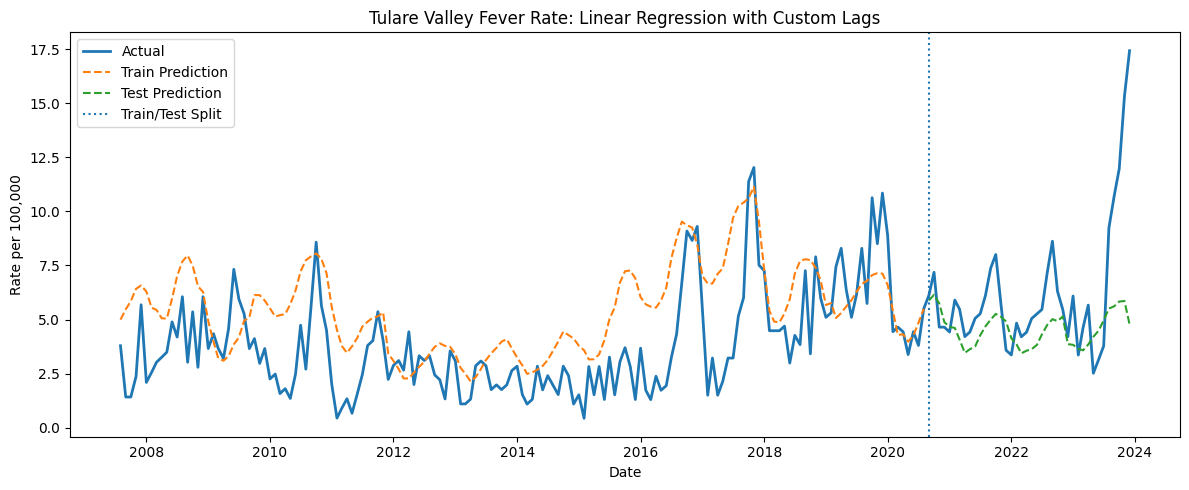

Tulare original-scale test RMSE: 3.1583
Tulare log-difference test RMSE: 0.2351


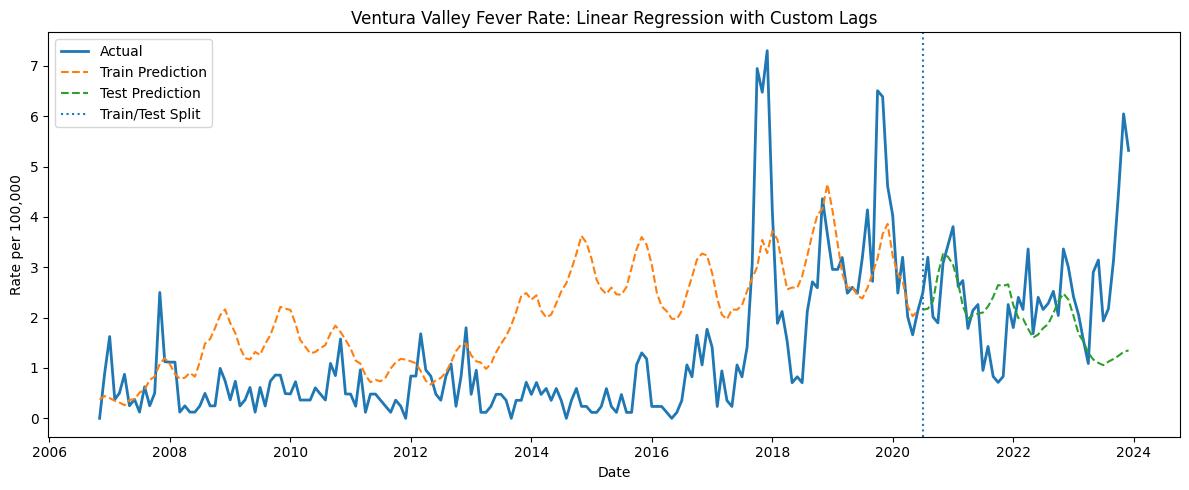

Ventura original-scale test RMSE: 1.3958
Ventura log-difference test RMSE: 0.2489


In [ ]:
import matplotlib.pyplot as plt

for county in all_county_predictions_df["County"].unique():

    county_predictions = (all_county_predictions_df[all_county_predictions_df["County"] == county].sort_values("Year-Month"))

    train_predictions = county_predictions[county_predictions["Dataset"] == "Train"]

    test_predictions = county_predictions[county_predictions["Dataset"] == "Test"]

    county_metrics = all_county_metrics_df[all_county_metrics_df["County"] == county].iloc[0]

    plt.figure(figsize=(12, 5))

    # Actual values across train and test
    plt.plot(
        county_predictions["Year-Month"],
        county_predictions["Actual_Rate"],
        label="Actual",
        linewidth=2
    )

    # Training predictions
    plt.plot(
        train_predictions["Year-Month"],
        train_predictions["Predicted_Rate"],
        label="Train Prediction",
        linestyle="--"
    )

    # Testing predictions
    plt.plot(
        test_predictions["Year-Month"],
        test_predictions["Predicted_Rate"],
        label="Test Prediction",
        linestyle="--"
    )

    # Mark the train/test boundary
    plt.axvline(
        test_predictions["Year-Month"].min(),
        linestyle=":",
        label="Train/Test Split"
    )

    plt.title(
        f"{county} Valley Fever Rate: "
        "Linear Regression with Custom Lags"
    )

    plt.xlabel("Date")
    plt.ylabel("Rate per 100,000")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"{county} original-scale test RMSE: "
        f"{county_metrics['Original_Scale_RMSE']:.4f}"
    )

    print(
        f"{county} log-difference test RMSE: "
        f"{county_metrics['Log_Difference_RMSE']:.4f}"
    )

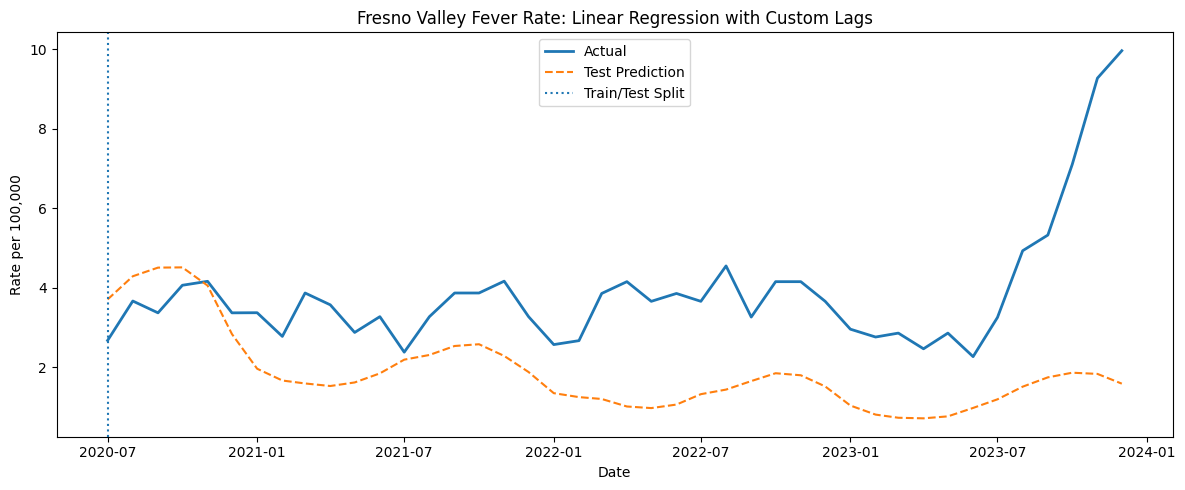

Fresno original-scale test RMSE: 2.6759
Fresno log-difference test RMSE: 0.1627


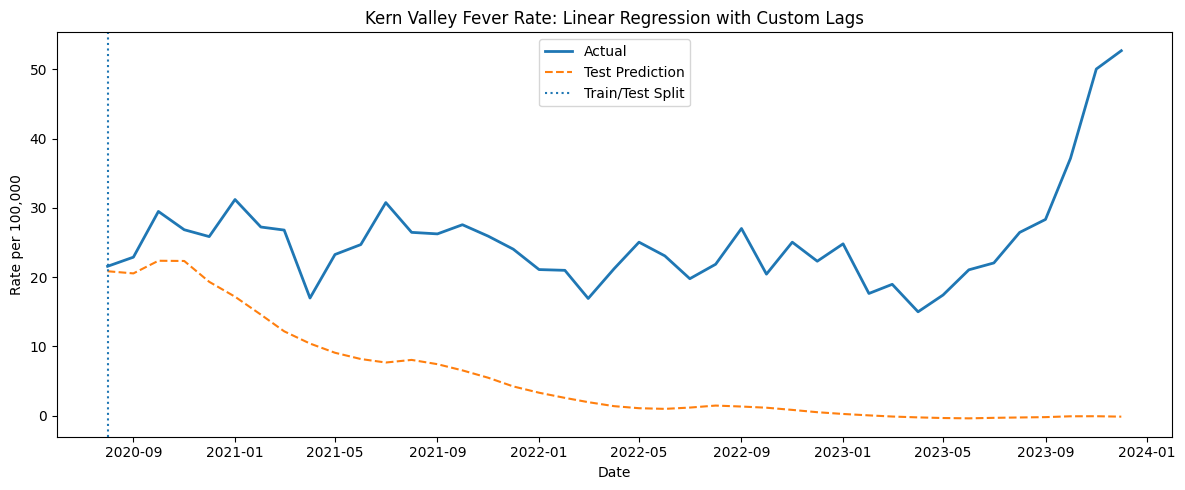

Kern original-scale test RMSE: 22.0195
Kern log-difference test RMSE: 0.2009


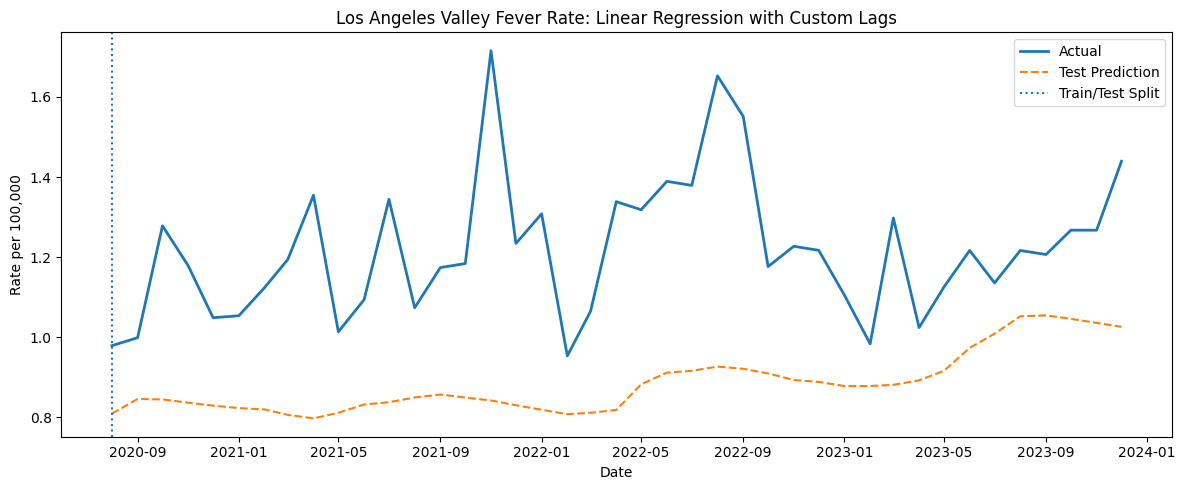

Los Angeles original-scale test RMSE: 0.3733
Los Angeles log-difference test RMSE: 0.0886


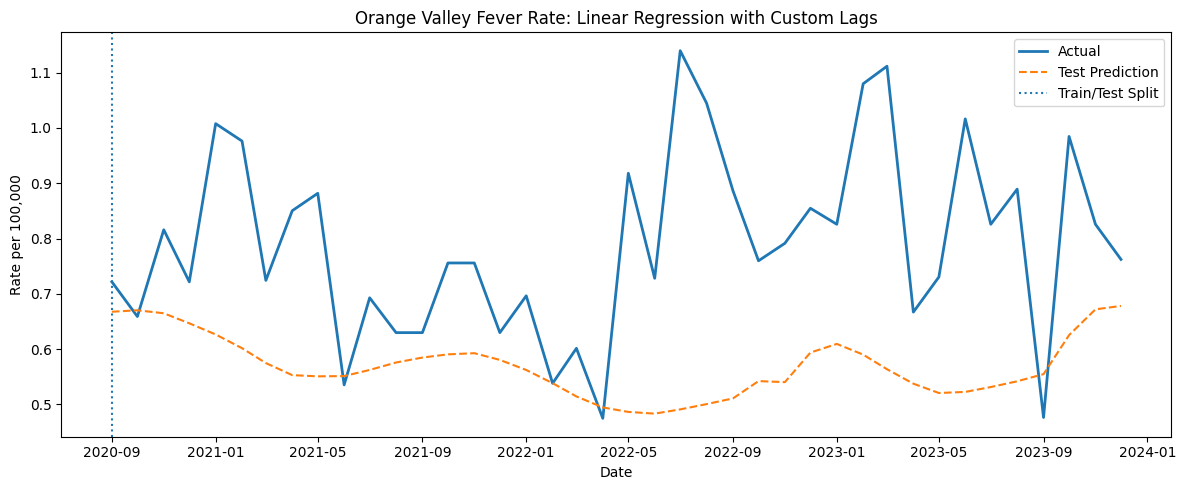

Orange original-scale test RMSE: 0.2824
Orange log-difference test RMSE: 0.1157


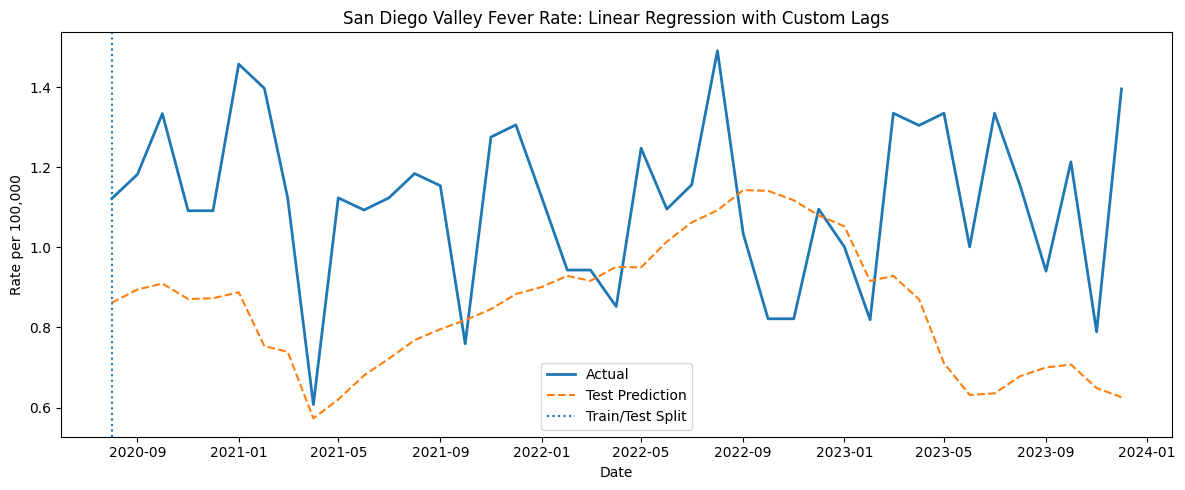

San Diego original-scale test RMSE: 0.3705
San Diego log-difference test RMSE: 0.1325


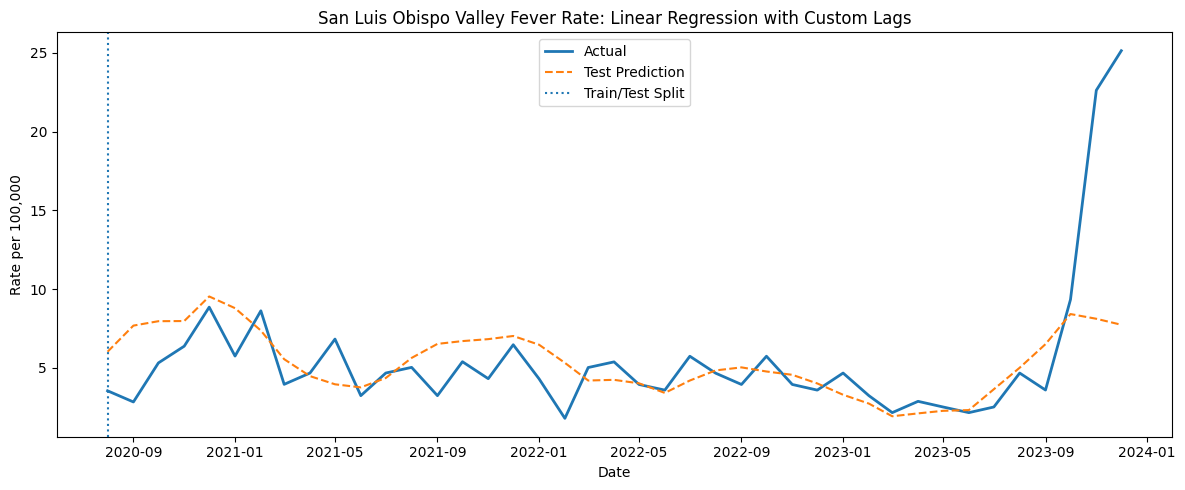

San Luis Obispo original-scale test RMSE: 3.9267
San Luis Obispo log-difference test RMSE: 0.3680


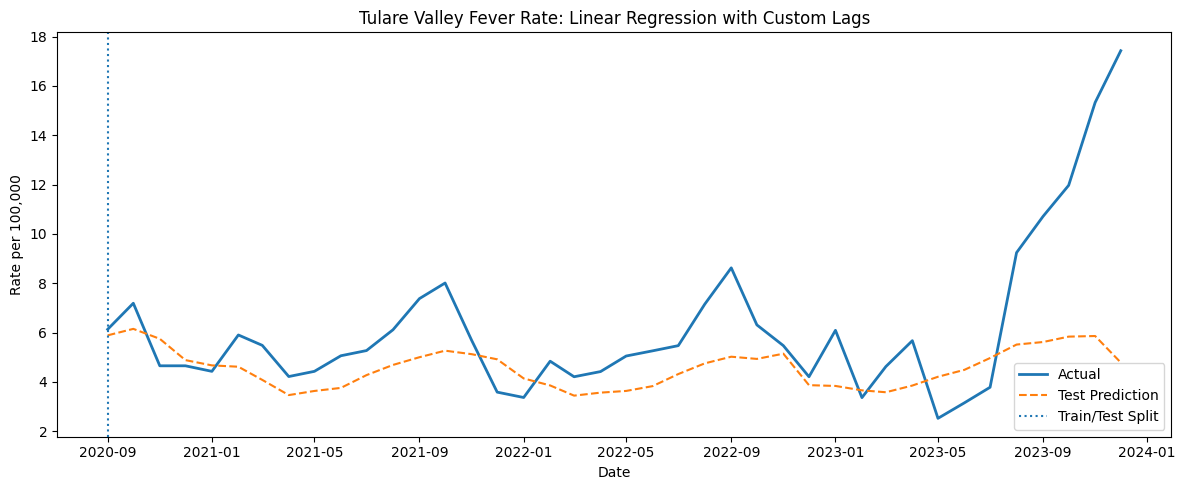

Tulare original-scale test RMSE: 3.1583
Tulare log-difference test RMSE: 0.2351


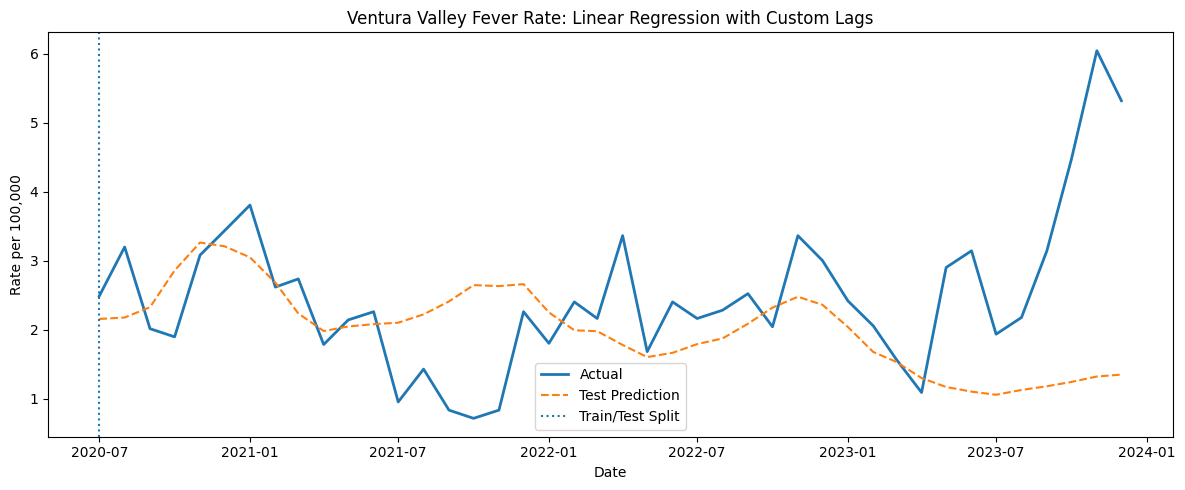

Ventura original-scale test RMSE: 1.3958
Ventura log-difference test RMSE: 0.2489


In [ ]:
import matplotlib.pyplot as plt

for county in all_county_predictions_df["County"].unique():

    county_predictions = (
        all_county_predictions_df[
            all_county_predictions_df["County"] == county
        ]
        .sort_values("Year-Month")
    )

    train_predictions = county_predictions[
        county_predictions["Dataset"] == "Train"
    ]

    test_predictions = county_predictions[
        county_predictions["Dataset"] == "Test"
    ]

    county_metrics = all_county_metrics_df[
        all_county_metrics_df["County"] == county
    ].iloc[0]

    plt.figure(figsize=(12, 5))

    # actual values across test
    plt.plot(
        test_predictions["Year-Month"],
        test_predictions["Actual_Rate"],
        label="Actual",
        linewidth=2
    )

    # Testing predictions
    plt.plot(
        test_predictions["Year-Month"],
        test_predictions["Predicted_Rate"],
        label="Test Prediction",
        linestyle="--"
    )

    # Mark the train/test boundary
    plt.axvline(
        test_predictions["Year-Month"].min(),
        linestyle=":",
        label="Train/Test Split"
    )

    plt.title(
        f"{county} Valley Fever Rate: "
        "Linear Regression with Custom Lags"
    )

    plt.xlabel("Date")
    plt.ylabel("Rate per 100,000")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"{county} original-scale test RMSE: "
        f"{county_metrics['Original_Scale_RMSE']:.4f}"
    )

    print(
        f"{county} log-difference test RMSE: "
        f"{county_metrics['Log_Difference_RMSE']:.4f}"
    )

# plot of LSTM and LR on fresno

In [ ]:
fresno_lstm_preds = pd.read_csv('/content/drive/MyDrive/DSSI/Project/code/fresno_lstm_predictions_using_screened_variables.csv', parse_dates=['Year-Month'])
fresno_lstm_preds

,Unnamed: 0,Year-Month,Actual,Predicted,County
0,0,2020-12-01,3.370832,4.170192,Fresno
1,1,2021-01-01,3.373933,3.775573,Fresno
2,2,2021-02-01,2.778533,3.328829,Fresno
3,3,2021-03-01,3.870100,3.023774,Fresno
4,4,2021-04-01,3.572400,2.897649,Fresno
5,5,2021-05-01,2.877766,2.896439,Fresno
6,6,2021-06-01,3.274700,3.128920,Fresno
7,7,2021-07-01,2.381600,2.927976,Fresno
8,8,2021-08-01,3.274700,3.150628,Fresno
9,9,2021-09-01,3.870100,3.647488,Fresno


In [ ]:
county = "Fresno"

fresno_predictions = all_county_predictions_df[
    all_county_predictions_df["County"] == county
].sort_values("Year-Month")

train_predictions = fresno_predictions[
    fresno_predictions["Dataset"] == "Train"
]

test_predictions = fresno_predictions[
    fresno_predictions["Dataset"] == "Test"
]

fresno_metrics = all_county_metrics_df[
    all_county_metrics_df["County"] == county
].iloc[0]

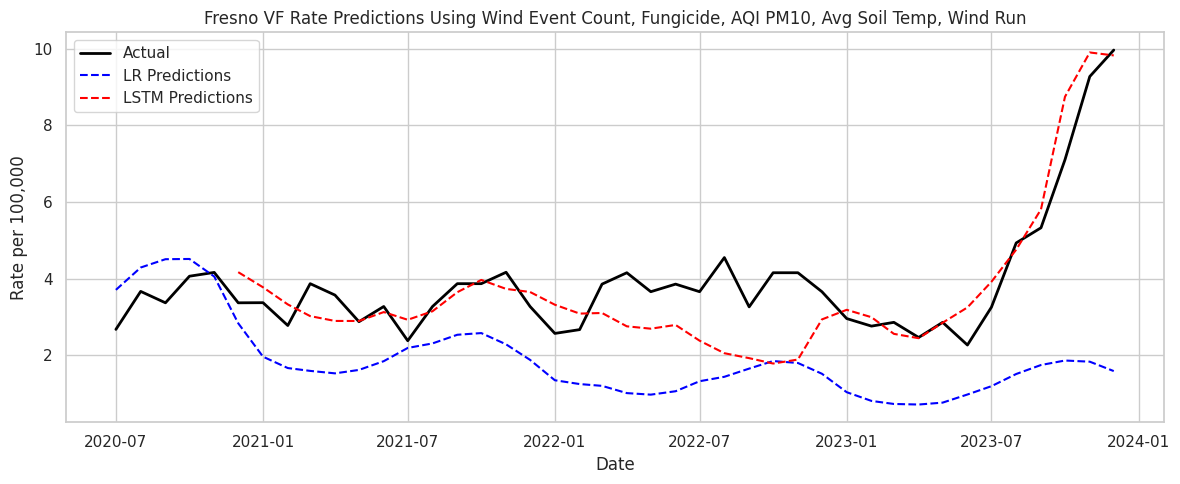

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.plot(
    test_predictions["Year-Month"],
    test_predictions["Actual_Rate"],
    label="Actual",
    color='Black',
    linewidth=2
)

plt.plot(
    test_predictions["Year-Month"],
    test_predictions["Predicted_Rate"],
    label="LR Predictions",
    color="Blue",
    linestyle="--"
)

plt.plot(
    fresno_lstm_preds["Year-Month"],
    fresno_lstm_preds["Predicted"],
    label="LSTM Predictions",
    color="Red",
    linestyle="--"
)

plt.title("Fresno VF Rate Predictions Using Wind Event Count, Fungicide, AQI PM10, Avg Soil Temp, Wind Run")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()
plt.tight_layout()
plt.show()

# new LR model function

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [17]:
def make_custom_lag_matrix(df, target_col, lag_dict, drop_na=False):
    """
    Build a lagged feature matrix using custom lags for selected columns.

    Parameters
    ----------
    df : pd.DataFrame
        Time-ordered dataframe.

    target_col : str
        Column name of the variable to forecast.

    lag_dict : dict
        Dictionary where:
            key   = column name
            value = either:
                - an int (creates lags 1 through value)
                - a list of specific lags

        Example:
        {
            "log1p_rate_per_100k": 12,
            "Precipitation": [3, 6, 12],
            "Avg Soil Temp (F)": 3,
            "AQI_PM25": 1
        }

    drop_na : bool, default=False
        If True, removes rows containing NaN lag values.

    Returns
    -------
    X : pd.DataFrame
        Lagged feature matrix.

    y : pd.Series
        Current (unshifted) target values.
    """

    lagged_frames = []

    for col, lags in lag_dict.items():

        # If an integer is supplied, create lags 1 through that integer
        if isinstance(lags, int):
            lags = range(1, lags + 1)

        # Otherwise assume lags is already an iterable (list, tuple, etc.)
        for lag in lags:
            shifted = df[[col]].shift(lag)
            shifted.columns = [f"{col}_lag{lag}"]
            lagged_frames.append(shifted)

    X = pd.concat(lagged_frames, axis=1)
    y = df[target_col]

    if drop_na:
        combined = pd.concat([X, y], axis=1).dropna()
        X = combined.drop(columns=[target_col])
        y = combined[target_col]

    return X, y

In [29]:
def train_lr_recursive_forecast(
        df,
        lag_dict,
        target_col="rate_per_100k",
        date_col="Year-Month",
        train_frac=0.80,
        plot=True,
        verbose=True,
        title="Recursive Linear Regression Forecast"
):
    model_df = (
        df.copy()
        .sort_values(date_col)
        .reset_index(drop=True)
    )

    model_df[date_col] = pd.to_datetime(model_df[date_col])

    # Create the transformed target
    model_df["log1p_target"] = np.log1p(model_df[target_col])
    model_df["log1p_diff_target"] = model_df["log1p_target"].diff()

    # Build the custom lag matrix
    X_lagged, y_diff = make_custom_lag_matrix(
        df=model_df,
        target_col="log1p_diff_target",
        lag_dict=lag_dict,
        drop_na=False
    )

    # Keep dates, original target, logged target, and original row positions
    modeling_data = pd.concat(
        [
            model_df[
                [
                    date_col,
                    target_col,
                    "log1p_target",
                    "log1p_diff_target"
                ]
            ],
            X_lagged
        ],
        axis=1
    )

    modeling_data["original_row"] = modeling_data.index

    modeling_data = (
        modeling_data
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )

    feature_names = list(X_lagged.columns)

    split = int(train_frac * len(modeling_data))

    if split <= 0 or split >= len(modeling_data):
        raise ValueError(
            "The split must leave both training and test observations."
        )

    train_df = modeling_data.iloc[:split].copy()
    test_df = modeling_data.iloc[split:].copy()

    X_train = train_df[feature_names]
    X_test = test_df[feature_names]

    y_train_diff = train_df["log1p_diff_target"]
    y_test_diff = test_df["log1p_diff_target"]

    model = LinearRegression()

    model.fit(X_train, y_train_diff)

    train_predicted_diff = model.predict(X_train)
    test_predicted_diff = model.predict(X_test)

    # ---------------------------------------------------------
    # RMSE before back-transformation
    # Scale: first difference of log1p(rate)
    # ---------------------------------------------------------
    train_rmse_transformed = np.sqrt(
        mean_squared_error(
            y_train_diff,
            train_predicted_diff
        )
    )

    test_rmse_transformed = np.sqrt(
        mean_squared_error(
            y_test_diff,
            test_predicted_diff
        )
    )

    # ---------------------------------------------------------
    # Recursive training reconstruction
    # ---------------------------------------------------------
    first_train_original_row = int(
        train_df["original_row"].iloc[0]
    )

    train_starting_log_rate = model_df.loc[
        first_train_original_row - 1,
        "log1p_target"
    ]

    train_predicted_log_rate = (
        train_starting_log_rate
        + np.cumsum(train_predicted_diff)
    )

    train_predicted_rate = np.expm1(
        train_predicted_log_rate
    )

    # ---------------------------------------------------------
    # Recursive test reconstruction
    #
    # Start from the final actual training target and then use
    # only predicted test differences.
    # ---------------------------------------------------------
    last_train_log_rate = train_df[
        "log1p_target"
    ].iloc[-1]

    test_predicted_log_rate = (
        last_train_log_rate
        + np.cumsum(test_predicted_diff)
    )

    test_predicted_rate = np.expm1(
        test_predicted_log_rate
    )

    train_predicted_rate = np.maximum(
        train_predicted_rate,
        0
    )

    test_predicted_rate = np.maximum(
        test_predicted_rate,
        0
    )

    y_train_original = train_df[
        target_col
    ].to_numpy()

    y_test_original = test_df[
        target_col
    ].to_numpy()

    # ---------------------------------------------------------
    # Metrics after recursive back-transformation
    # Scale: original rate per 100,000
    # ---------------------------------------------------------
    train_rmse_original = np.sqrt(
        mean_squared_error(
            y_train_original,
            train_predicted_rate
        )
    )

    train_mae_original = mean_absolute_error(
        y_train_original,
        train_predicted_rate
    )

    train_r2_original = r2_score(
        y_train_original,
        train_predicted_rate
    )

    test_rmse_original = np.sqrt(
        mean_squared_error(
            y_test_original,
            test_predicted_rate
        )
    )

    test_mae_original = mean_absolute_error(
        y_test_original,
        test_predicted_rate
    )

    test_r2_original = r2_score(
        y_test_original,
        test_predicted_rate
    )

    train_results = pd.DataFrame({
        date_col: train_df[date_col].to_numpy(),
        "Actual_Log1p_Difference": y_train_diff.to_numpy(),
        "Predicted_Log1p_Difference": train_predicted_diff,
        "Actual_Rate": y_train_original,
        "Predicted_Rate": train_predicted_rate,
        "Dataset": "Train"
    })

    test_results = pd.DataFrame({
        date_col: test_df[date_col].to_numpy(),
        "Actual_Log1p_Difference": y_test_diff.to_numpy(),
        "Predicted_Log1p_Difference": test_predicted_diff,
        "Actual_Rate": y_test_original,
        "Predicted_Rate": test_predicted_rate,
        "Dataset": "Test"
    })

    results = pd.concat(
        [train_results, test_results],
        ignore_index=True
    )

    coefficients = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    }).sort_values(
        "Coefficient",
        key=np.abs,
        ascending=False
    ).reset_index(drop=True)

    if verbose:
        print(f"Training observations: {len(train_df)}")
        print(f"Test observations: {len(test_df)}")
        print(f"Number of lagged features: {len(feature_names)}")

        print("\nBefore recursive back-transformation")
        print(
            f"Train log1p-difference RMSE: "
            f"{train_rmse_transformed:.4f}"
        )
        print(
            f"Test log1p-difference RMSE:  "
            f"{test_rmse_transformed:.4f}"
        )

        print("\nAfter recursive back-transformation")
        print(
            f"Train original-scale RMSE: "
            f"{train_rmse_original:.4f}"
        )
        print(
            f"Train original-scale MAE:  "
            f"{train_mae_original:.4f}"
        )
        print(
            f"Train original-scale R²:   "
            f"{train_r2_original:.4f}"
        )

        print()

        print(
            f"Test original-scale RMSE:  "
            f"{test_rmse_original:.4f}"
        )
        print(
            f"Test original-scale MAE:   "
            f"{test_mae_original:.4f}"
        )
        print(
            f"Test original-scale R²:    "
            f"{test_r2_original:.4f}"
        )

    if plot:
        fig, ax = plt.subplots(figsize=(14, 6))

        ax.plot(
            results[date_col],
            results["Actual_Rate"],
            label="Actual",
            linewidth=2
        )

        ax.plot(
            train_results[date_col],
            train_results["Predicted_Rate"],
            label="Recursive Training Prediction",
            linestyle="--"
        )

        ax.plot(
            test_results[date_col],
            test_results["Predicted_Rate"],
            label="Recursive Test Prediction",
            linestyle="--"
        )

        ax.axvline(
            test_results[date_col].iloc[0],
            linestyle=":",
            label="Train/Test Split"
        )

        ax.set_title(title)
        ax.set_xlabel("Month")
        ax.set_ylabel("Rate per 100,000")
        ax.grid(True, alpha=0.3)
        ax.legend()

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%Y-%m")
        )

        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

    return {
        "model": model,
        "results": results,
        "train_results": train_results,
        "test_results": test_results,
        "coefficients": coefficients,
        "feature_names": feature_names,
        "X_train": X_train,
        "X_test": X_test,
        "y_train_transformed": y_train_diff,
        "y_test_transformed": y_test_diff,
        "train_predicted_diff": train_predicted_diff,
        "test_predicted_diff": test_predicted_diff,
        "train_rmse_transformed": train_rmse_transformed,
        "test_rmse_transformed": test_rmse_transformed,
        "train_rmse_original": train_rmse_original,
        "train_mae_original": train_mae_original,
        "train_r2_original": train_r2_original,
        "rmse": test_rmse_original,
        "mae": test_mae_original,
        "r2": test_r2_original
    }

In [40]:
selected_lags_by_county = {
    "Fresno": {
        "windeventcount": [0],
        "fungicide_lbs_prd_used": [0],
        "AQI_PM10": [0],
        "Avg Soil Temp (F)": [0],
        "Wind Run (miles)": [0]
    },

    "Kern": {
        "Avg Rel Hum (%)": [0],
        "fungicide_lbs_prd_used": [0],
        "Avg Soil Temp (F)": [0]
    },

    "Los Angeles": {
        "Avg Wind Speed (mph)": [0],
        "Precipitation": [0],
        "AQI_PM10": [0]
    },

    "Orange": {
        "Avg Soil Temp (F)": [0],
        "rodent_lbs_prd_used": [0],
        "FIRE_Acres_Burned": [0],
        "windeventcount": [0]
    },

    "San Diego": {
        "windeventcount": [0],
        "fungicide_lbs_prd_used": [0],
        "Avg Soil Temp (F)": [0],
        "AQI_PM10": [0]
    },

    "San Luis Obispo": {
        "fungicide_lbs_prd_used": [0],
        "Avg Soil Temp (F)": [0],
        "Avg Rel Hum (%)": [0],
        "windeventcount": [0]
    },

    "Tulare": {
        "Avg Soil Temp (F)": [0],
        "Precipitation": [0],
        "windeventcount": [0],
        "Avg Wind Speed (mph)": [0]
    },

    "Ventura": {
        "AQI_PM10": [0],
        "FIRE_Acres_Burned": [0],
        "Avg Rel Hum (%)": [0]
    }
}

In [35]:
selected_lags_by_county = {
    "Fresno": {
        "windeventcount": 3,
        "fungicide_lbs_prd_used": 3,
        "AQI_PM10": 3,
        "Avg Soil Temp (F)": 3,
        "Wind Run (miles)": 3
    },

    "Kern": {
        "Avg Rel Hum (%)": 4,
        "fungicide_lbs_prd_used": 4,
        "Avg Soil Temp (F)": 6
    },

    "Los Angeles": {
        "Avg Wind Speed (mph)": 1,
        "Precipitation": 5,
        "AQI_PM10": 5
    },

    "Orange": {
        "Avg Soil Temp (F)":6,
        "rodent_lbs_prd_used":6,
        "FIRE_Acres_Burned":6,
        "windeventcount": 6
    },

    "San Diego": {
        "windeventcount": 3,
        "fungicide_lbs_prd_used": 3,
        "Avg Soil Temp (F)": 5,
        "AQI_PM10": 5
    },

    "San Luis Obispo": {
        "fungicide_lbs_prd_used": 4,
        "Avg Soil Temp (F)": 4,
        "Avg Rel Hum (%)": 4,
        "windeventcount": 4
    },

    "Tulare": {
        "Avg Soil Temp (F)": 6,
        "Precipitation": 6,
        "windeventcount": 6,
        "Avg Wind Speed (mph)": 6
    },

    "Ventura": {
        "AQI_PM10": 1,
        "FIRE_Acres_Burned": 1,
        "Avg Rel Hum (%)": 3
    }
}

In [41]:
custom_lags_by_county = {
    county: {
        feature: [lag]
        for feature, lag in county_lags.items()
    }
    for county, county_lags in selected_lags_by_county.items()
}

In [42]:
def run_lr_recursive_all_counties(
        df,
        lag_dict_by_county,
        county_col="County",
        target_col="rate_per_100k",
        date_col="Year-Month",
        train_frac=0.80,
        plot=True,
        verbose=True
):
    all_county_results = {}
    all_county_metrics = []
    all_county_predictions = []

    for county, lag_dict in lag_dict_by_county.items():
        print(f"\nRunning {county}...")

        county_df = (
            df[df[county_col] == county]
            .copy()
            .sort_values(date_col)
            .reset_index(drop=True)
        )

        county_result = train_lr_recursive_forecast(
            df=county_df,
            lag_dict=lag_dict,
            target_col=target_col,
            date_col=date_col,
            train_frac=train_frac,
            plot=plot,
            verbose=verbose,
            title=(
                f"{county} Valley Fever: "
                "Recursive Log1p-Difference Linear Regression"
            )
        )

        all_county_results[county] = county_result

        all_county_metrics.append({
            "County": county,
            "Train_RMSE_Transformed":
                county_result["train_rmse_transformed"],
            "Test_RMSE_Transformed":
                county_result["test_rmse_transformed"],
            "Train_RMSE_Original":
                county_result["train_rmse_original"],
            "Test_RMSE_Original":
                county_result["rmse"],
            "Test_MAE_Original":
                county_result["mae"],
            "Test_R2_Original":
                county_result["r2"],
            "Number_Lagged_Features":
                len(county_result["feature_names"]),
            "Lagged_Features":
                county_result["feature_names"],
            "Lag_Dictionary":
                lag_dict
        })

        county_predictions = (
            county_result["results"].copy()
        )

        county_predictions[county_col] = county

        all_county_predictions.append(
            county_predictions
        )

    metrics_df = pd.DataFrame(
        all_county_metrics
    )

    predictions_df = pd.concat(
        all_county_predictions,
        ignore_index=True
    )

    return {
        "by_county": all_county_results,
        "metrics": metrics_df,
        "predictions": predictions_df
    }


Running Fresno...
Training observations: 199
Test observations: 9
Number of lagged features: 5

Before recursive back-transformation
Train log1p-difference RMSE: 0.2582
Test log1p-difference RMSE:  0.1683

After recursive back-transformation
Train original-scale RMSE: 3.5623
Train original-scale MAE:  2.7137
Train original-scale R²:   -0.9811

Test original-scale RMSE:  2.8316
Test original-scale MAE:   1.9472
Test original-scale R²:    -0.0568


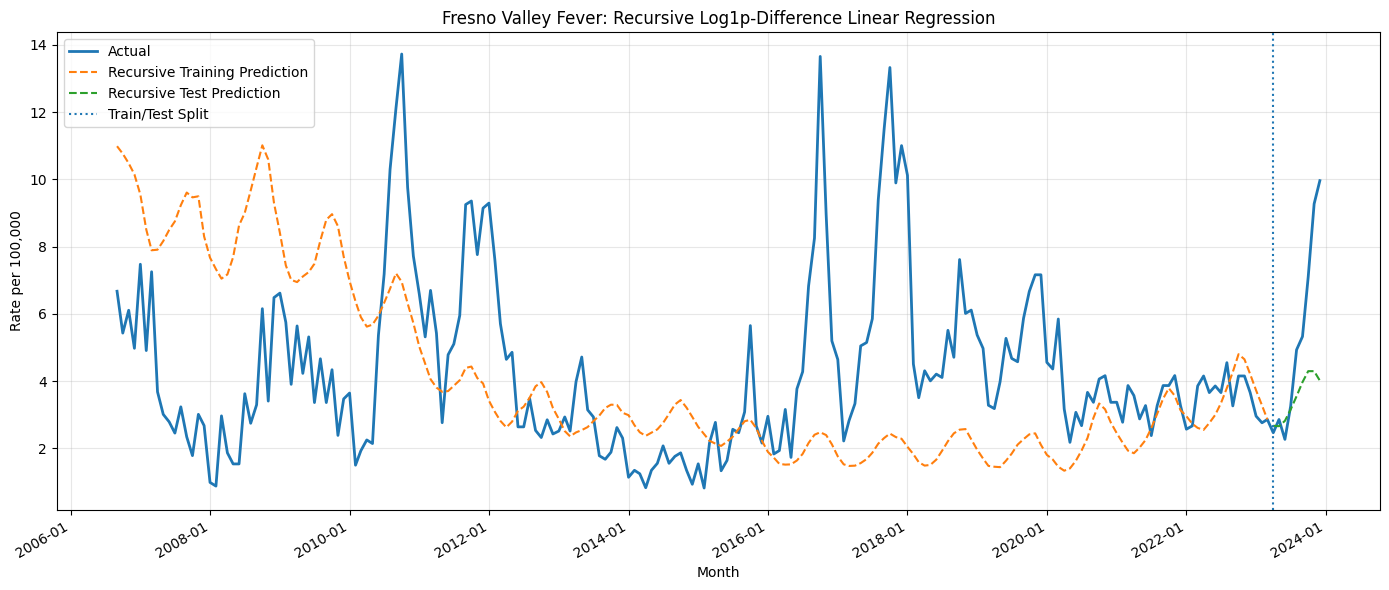


Running Kern...
Training observations: 199
Test observations: 9
Number of lagged features: 3

Before recursive back-transformation
Train log1p-difference RMSE: 0.2367
Test log1p-difference RMSE:  0.1591

After recursive back-transformation
Train original-scale RMSE: 11.3314
Train original-scale MAE:  8.7934
Train original-scale R²:   -0.2025

Test original-scale RMSE:  10.7862
Test original-scale MAE:   6.4363
Test original-scale R²:    0.3063


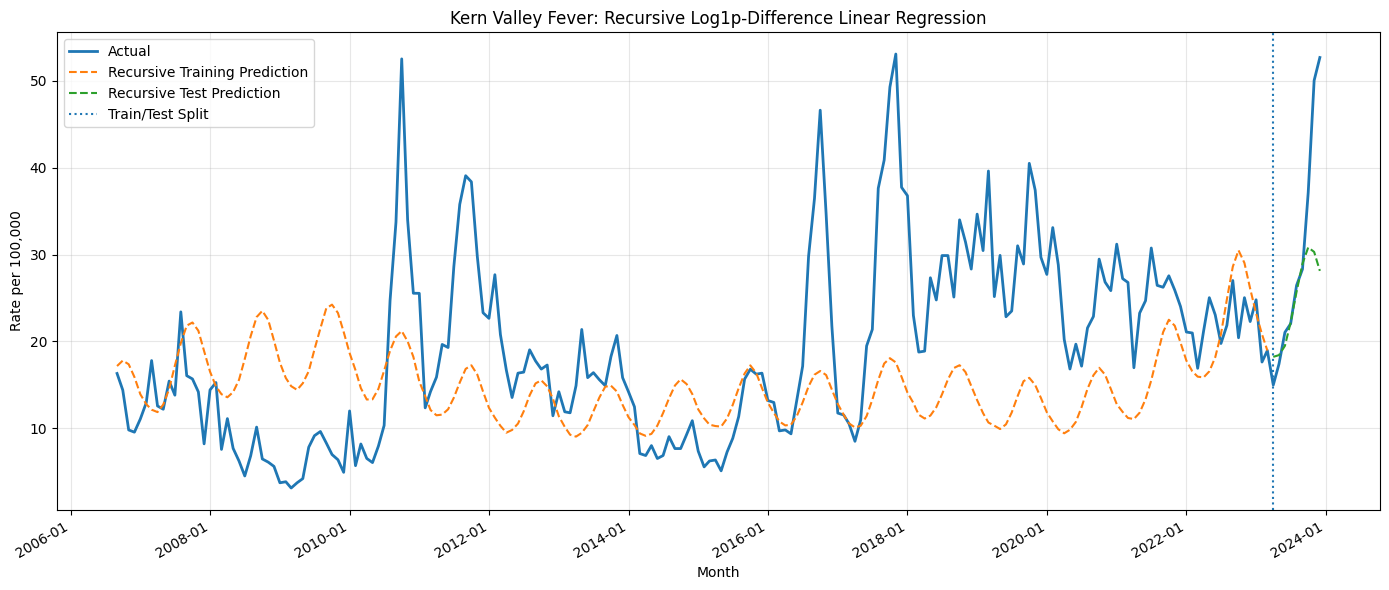


Running Los Angeles...
Training observations: 199
Test observations: 9
Number of lagged features: 3

Before recursive back-transformation
Train log1p-difference RMSE: 0.0767
Test log1p-difference RMSE:  0.0580

After recursive back-transformation
Train original-scale RMSE: 0.3491
Train original-scale MAE:  0.2907
Train original-scale R²:   0.2364

Test original-scale RMSE:  0.1571
Test original-scale MAE:   0.1421
Test original-scale R²:    -1.0829


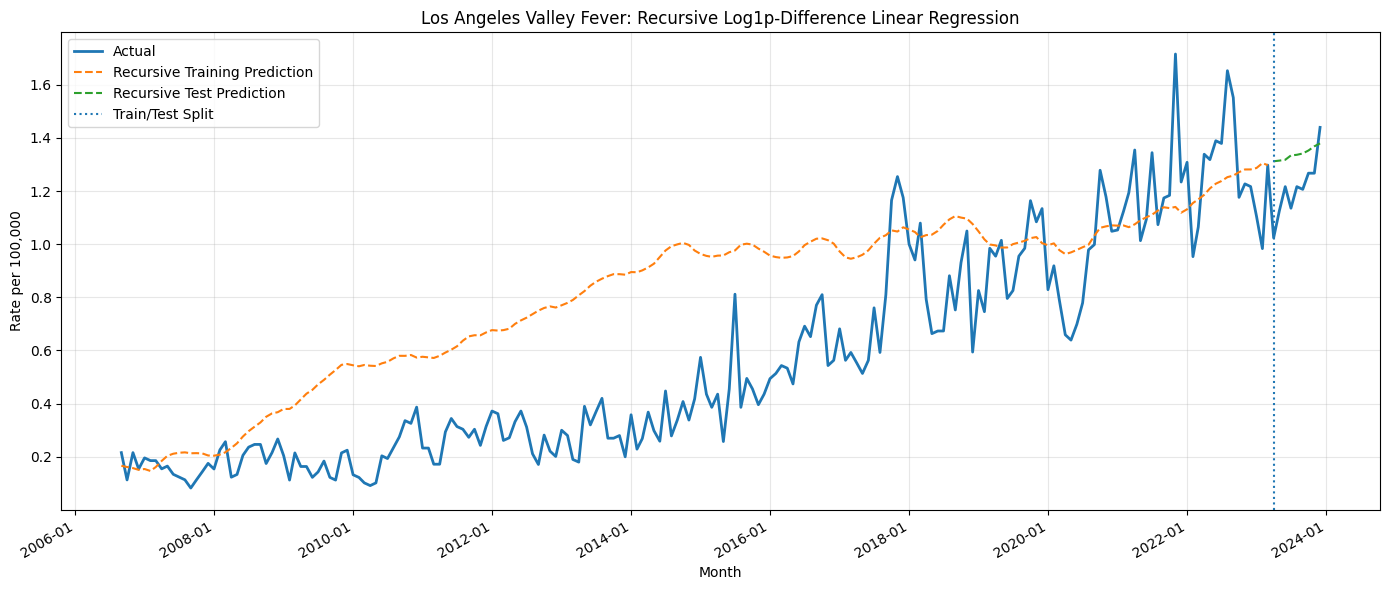


Running Orange...
Training observations: 199
Test observations: 9
Number of lagged features: 4

Before recursive back-transformation
Train log1p-difference RMSE: 0.1055
Test log1p-difference RMSE:  0.1688

After recursive back-transformation
Train original-scale RMSE: 0.1868
Train original-scale MAE:  0.1431
Train original-scale R²:   0.5647

Test original-scale RMSE:  0.4965
Test original-scale MAE:   0.4610
Test original-scale R²:    -9.1393


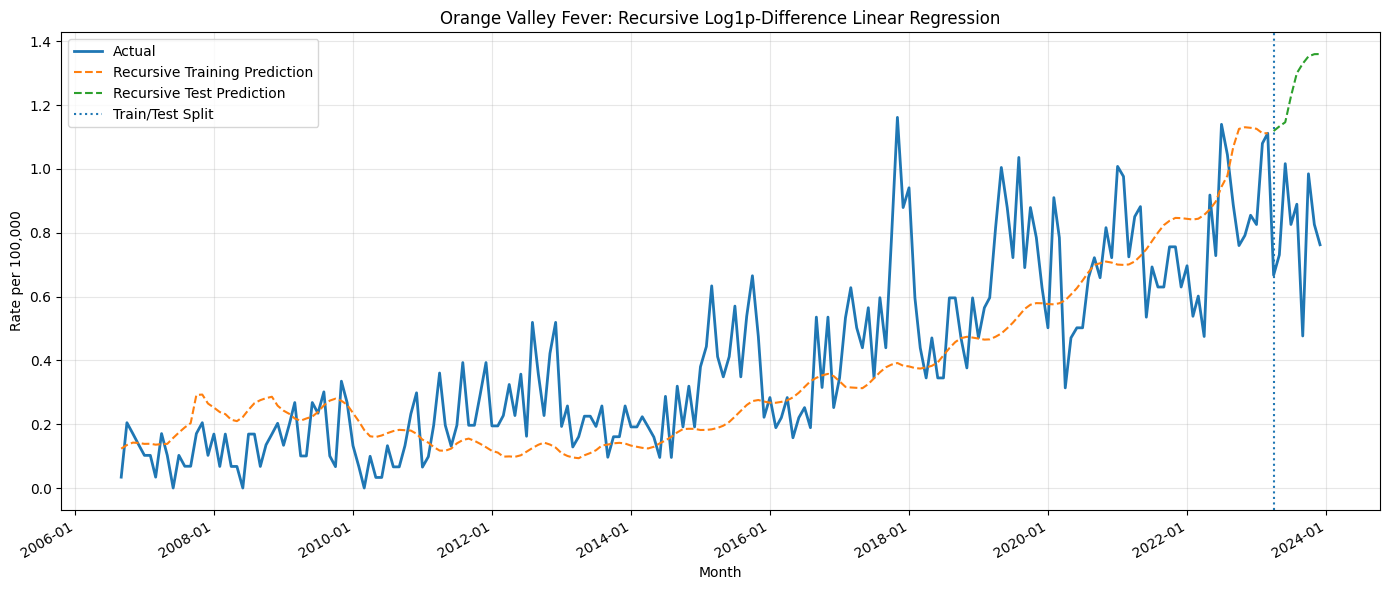


Running San Diego...
Training observations: 199
Test observations: 9
Number of lagged features: 4

Before recursive back-transformation
Train log1p-difference RMSE: 0.1165
Test log1p-difference RMSE:  0.1602

After recursive back-transformation
Train original-scale RMSE: 0.4959
Train original-scale MAE:  0.4201
Train original-scale R²:   -0.6696

Test original-scale RMSE:  0.3776
Test original-scale MAE:   0.2797
Test original-scale R²:    -2.6490


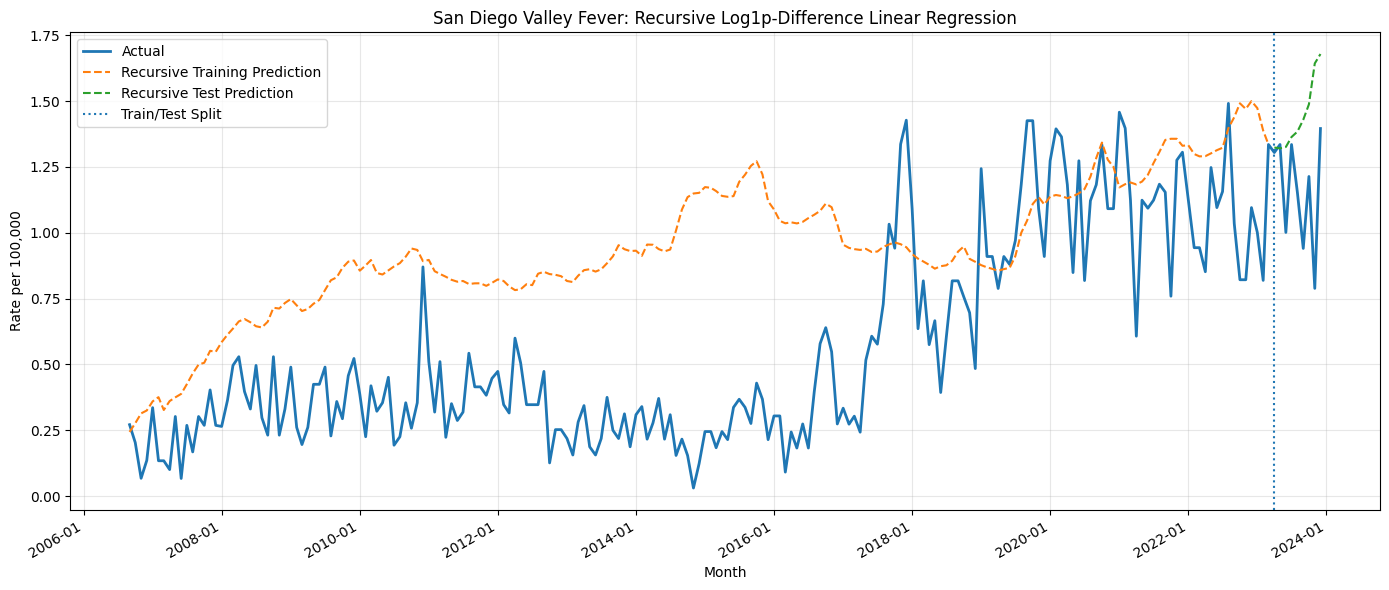


Running San Luis Obispo...
Training observations: 199
Test observations: 9
Number of lagged features: 4

Before recursive back-transformation
Train log1p-difference RMSE: 0.4548
Test log1p-difference RMSE:  0.4114

After recursive back-transformation
Train original-scale RMSE: 6.8073
Train original-scale MAE:  4.6154
Train original-scale R²:   -0.7743

Test original-scale RMSE:  9.6858
Test original-scale MAE:   5.3909
Test original-scale R²:    -0.2812


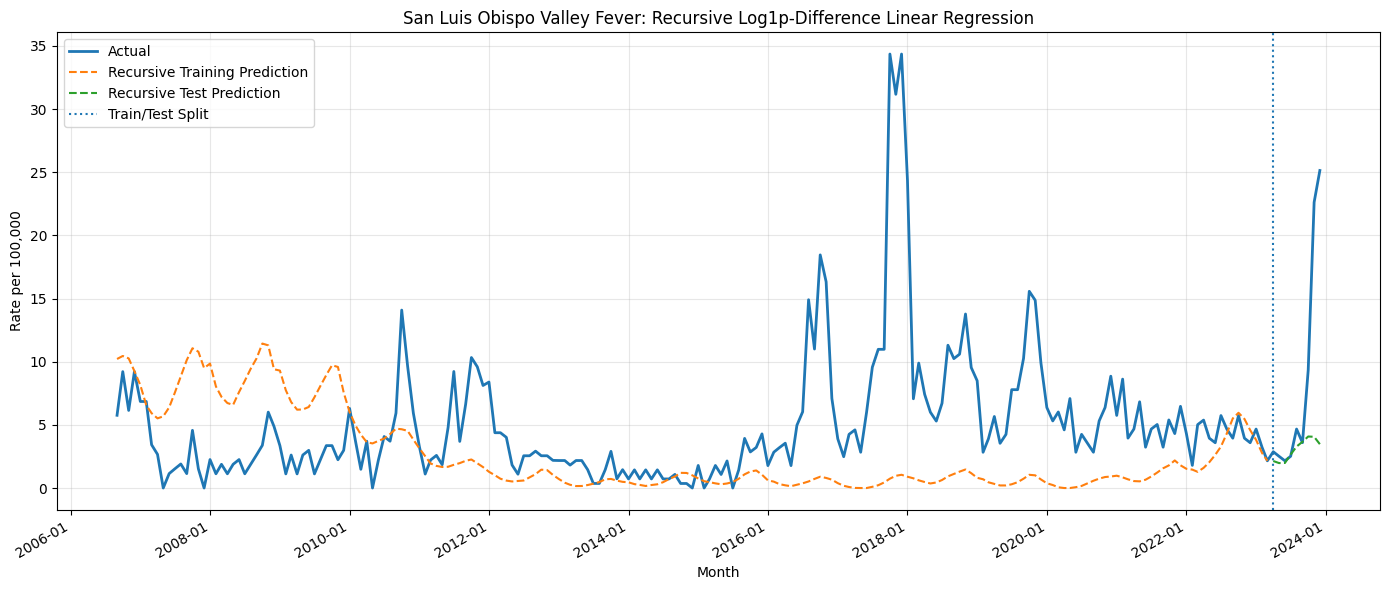


Running Tulare...
Training observations: 199
Test observations: 9
Number of lagged features: 4

Before recursive back-transformation
Train log1p-difference RMSE: 0.3249
Test log1p-difference RMSE:  0.3368

After recursive back-transformation
Train original-scale RMSE: 1.7439
Train original-scale MAE:  1.2674
Train original-scale R²:   0.3940

Test original-scale RMSE:  4.8304
Test original-scale MAE:   3.8827
Test original-scale R²:    0.1148


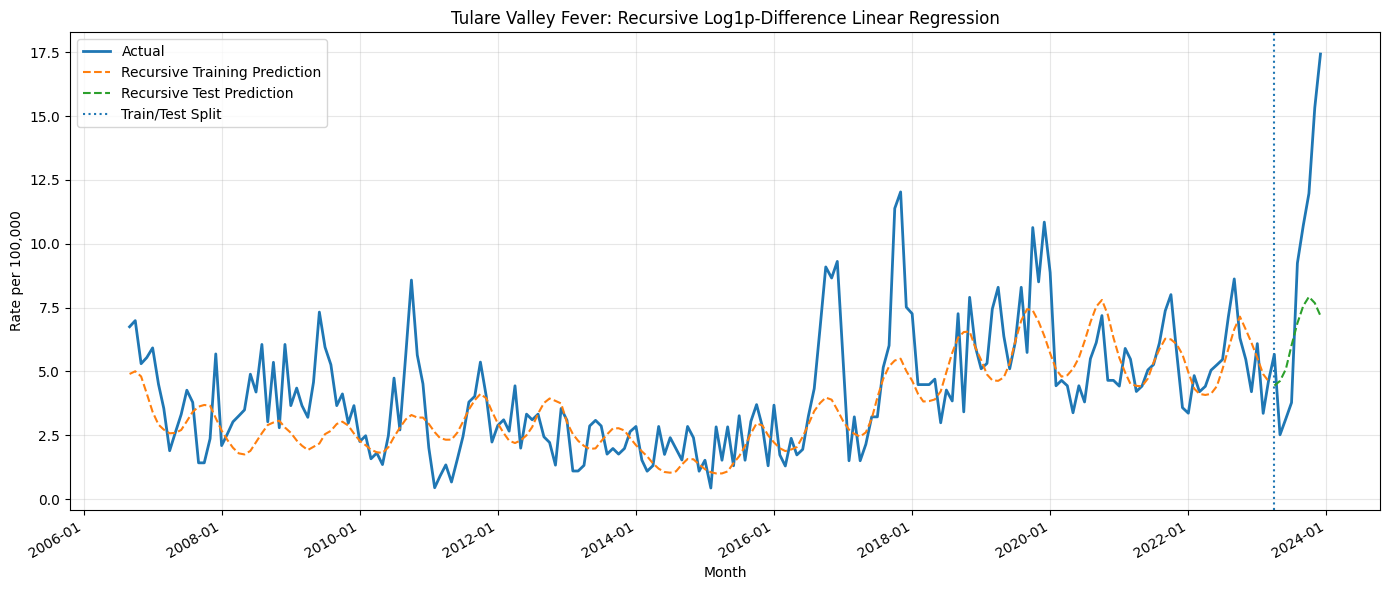


Running Ventura...
Training observations: 199
Test observations: 9
Number of lagged features: 3

Before recursive back-transformation
Train log1p-difference RMSE: 0.2810
Test log1p-difference RMSE:  0.3248

After recursive back-transformation
Train original-scale RMSE: 1.1151
Train original-scale MAE:  0.7408
Train original-scale R²:   0.3446

Test original-scale RMSE:  2.0569
Test original-scale MAE:   1.6406
Test original-scale R²:    -0.7957


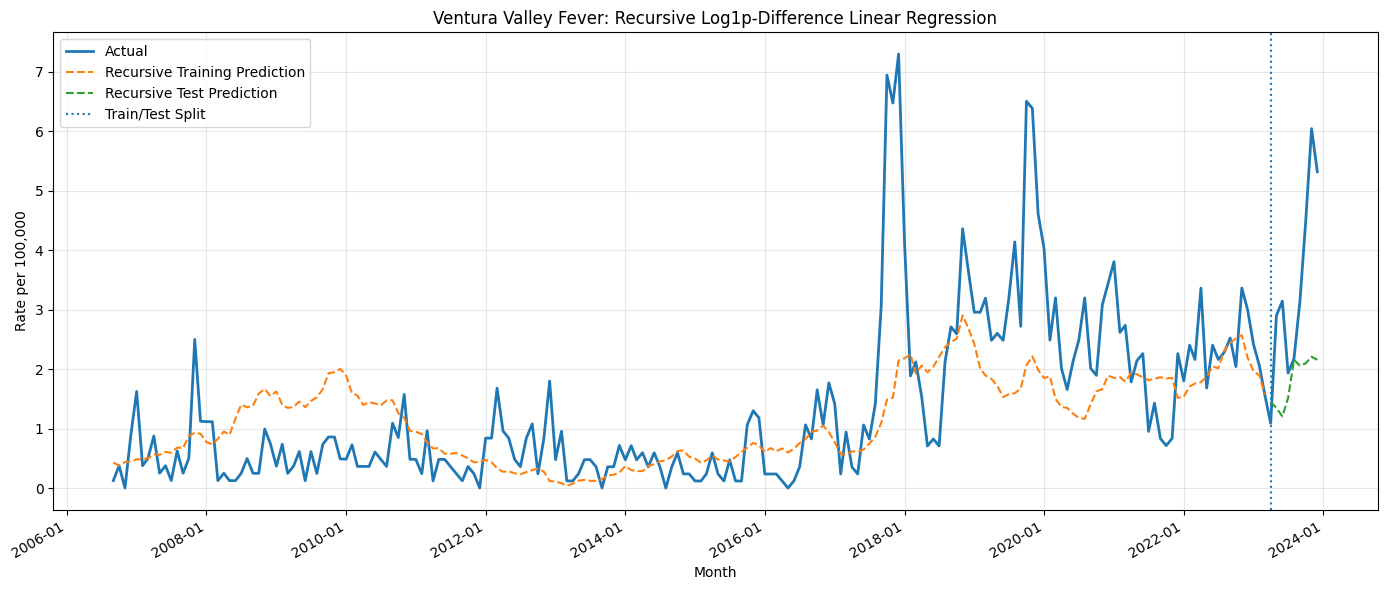

In [45]:
all_county_lr_results = run_lr_recursive_all_counties(
    df=aggregated_data_trimmed,
    lag_dict_by_county=custom_lags_by_county,
    county_col="County",
    target_col="rate_per_100k",
    date_col="Year-Month",
    train_frac=0.96,
    plot=True,
    verbose=True
)

In [44]:
all_county_lr_metrics_df = all_county_lr_results["metrics"]

display(
    all_county_lr_metrics_df
    .sort_values("Test_RMSE_Original")
    .reset_index(drop=True)
)

,County,Train_RMSE_Transformed,Test_RMSE_Transformed,Train_RMSE_Original,Test_RMSE_Original,Test_MAE_Original,Test_R2_Original,Number_Lagged_Features,Lagged_Features,Lag_Dictionary
0,San Diego,0.111579,0.144397,0.475413,0.349329,0.287963,-1.881652,4,"[windeventcount_lag[0], fungicide_lbs_prd_used...","{'windeventcount': [[0]], 'fungicide_lbs_prd_u..."
1,Orange,0.106206,0.126049,0.213795,0.411636,0.298426,-4.870823,4,"[Avg Soil Temp (F)_lag[0], rodent_lbs_prd_used...","{'Avg Soil Temp (F)': [[0]], 'rodent_lbs_prd_u..."
2,Los Angeles,0.072350,0.089114,0.321132,0.428247,0.387567,-4.533098,3,"[Avg Wind Speed (mph)_lag[0], Precipitation_la...","{'Avg Wind Speed (mph)': [[0]], 'Precipitation..."
3,Ventura,0.285673,0.272872,1.197330,1.544591,1.170190,-1.026970,3,"[AQI_PM10_lag[0], FIRE_Acres_Burned_lag[0], Av...","{'AQI_PM10': [[0]], 'FIRE_Acres_Burned': [[0]]..."
4,Tulare,0.344397,0.236169,2.084485,3.013837,1.939677,-0.006330,4,"[Avg Soil Temp (F)_lag[0], Precipitation_lag[0...","{'Avg Soil Temp (F)': [[0]], 'Precipitation': ..."
5,Fresno,0.273673,0.164164,3.791463,3.944238,3.457691,-5.446385,5,"[windeventcount_lag[0], fungicide_lbs_prd_used...","{'windeventcount': [[0]], 'fungicide_lbs_prd_u..."
6,San Luis Obispo,0.468891,0.388131,7.393587,24.209839,17.802257,-28.510498,4,"[fungicide_lbs_prd_used_lag[0], Avg Soil Temp ...","{'fungicide_lbs_prd_used': [[0]], 'Avg Soil Te..."
7,Kern,0.245866,0.181698,10.238752,35.236593,28.781496,-21.949100,3,"[Avg Rel Hum (%)_lag[0], fungicide_lbs_prd_use...","{'Avg Rel Hum (%)': [[0]], 'fungicide_lbs_prd_..."
